In [48]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [49]:
data = pd.read_csv(r'data/n90pol.csv').to_numpy()

In [50]:
attributes = data[:,0:2]
y = data[:,2]
m = len(attributes)


In [51]:
def num_bins(data,m):
    iqrs = stats.iqr(data,axis=0)
    bw= 2*iqrs/m**(1/3) #https://stats.stackexchange.com/questions/798/calculating-optimal-number-of-bins-in-a-histogram
    bins = int((data.max(axis=0) - data.min(axis=0)) / bw)+5
    return bins

def get_kde(data,m,h=None):
    std = np.std(data)
    
    if h == None:
        h= 1.06*std*m**(-1/5)

    kde = stats.gaussian_kde(data,bw_method=h/std) #https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
    return kde,h

Q2.1

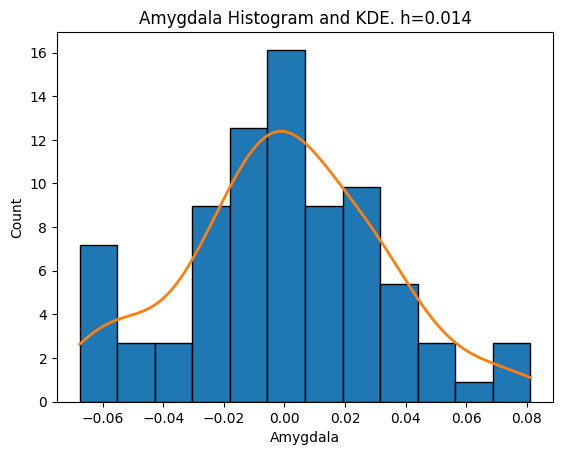

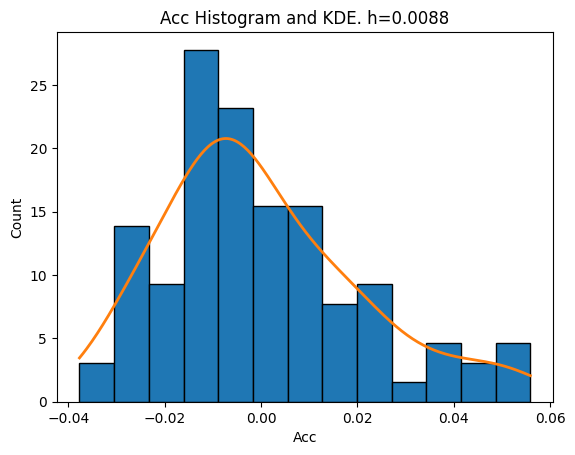

In [52]:
for i,attribute in zip(range(2),["Amygdala",'Acc']):
    bins_num=num_bins(attributes[:,i],m)
    kde,h = get_kde(attributes[:,i],m)
    plt.hist(attributes[:,i], bins=bins_num, density=True,edgecolor='black')
    xs = np.linspace(attributes[:,i].min(), attributes[:,i].max(), 250)
    plt.plot(xs, kde(xs), linewidth=2)
    plt.title(f"{attribute} Histogram and KDE. h={round(h,4)}")
    plt.ylabel('Count')
    plt.xlabel(attribute)

    plt.show()


Q2.2

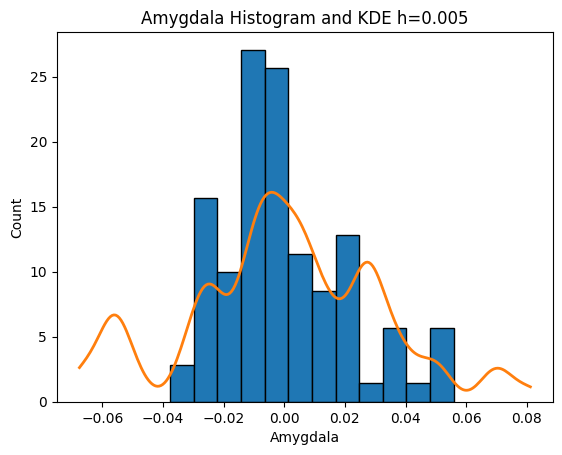

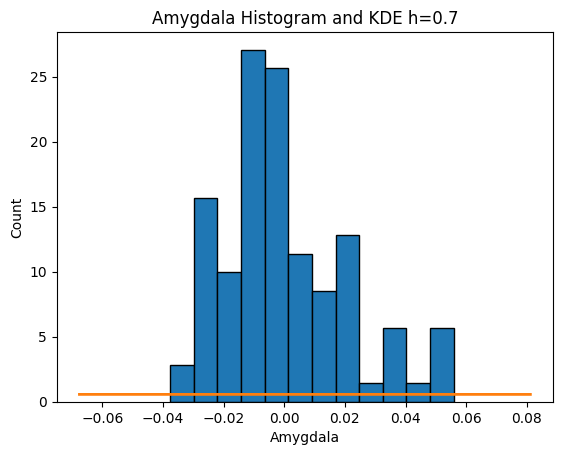

In [53]:
for hs in [.005,.70]:
    bins_num=num_bins(attributes[:,0],m)
    kde,h = get_kde(attributes[:,0],m,h=hs)
    plt.hist(attributes[:,i], bins=bins_num, density=True,edgecolor='black')
    xs = np.linspace(attributes[:,0].min(), attributes[:,0].max(), 250)
    plt.plot(xs, kde(xs), linewidth=2)
    plt.title(f"Amygdala Histogram and KDE h={round(hs,4)}")
    plt.ylabel('Count')
    plt.xlabel('Amygdala')

    plt.show()

Q2.3

Text(0.5, 0.92, 'Amygdala - Acc 2D Histogram')

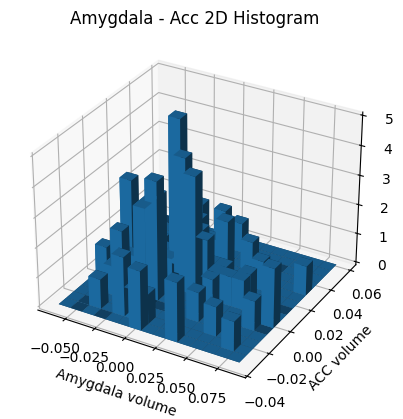

In [137]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
hist, xedges, yedges = np.histogram2d(data[:, 0], data[:, 1], bins=15)
xpos, ypos = np.meshgrid(xedges[:-1] + xedges[1:], yedges[:-1] + yedges[1:])
xpos = xpos.flatten() / 2.0
ypos = ypos.flatten() / 2.0
zpos = np.zeros_like(xpos)
dx = xedges[1] - xedges[0]
dy = yedges[1] - yedges[0]
dz = hist.flatten()
ax.set_xlabel('Amygdala volume')
ax.set_ylabel('ACC volume')
ax.bar3d(xpos, ypos, zpos, dx, dy, dz)
plt.title("Amygdala - Acc 2D Histogram")

Q2.4

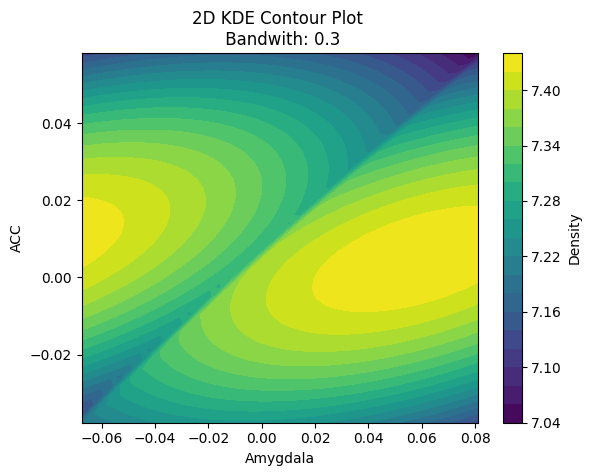

In [139]:
min_data = data[:,:2].min(0)
max_data = data[:,:2].max(0)

gridno = 40
inc1 = (max_data[0] - min_data[0]) / gridno
inc2 = (max_data[1] - min_data[1]) / gridno
gridx, gridy = np.meshgrid(
    np.arange(min_data[0], max_data[0] + inc1, inc1),
    np.arange(min_data[1], max_data[1] + inc2, inc2),
)

gridall = [gridx.flatten(order="F"), gridy.flatten(order="F")]
gridall = (np.asarray(gridall)).T
gridallno, nn = gridall.shape
norm_pdata = (np.power(data[:,:2], 2)).sum(axis=1)
norm_gridall = (np.power(gridall, 2)).sum(axis=1)
cross = np.dot(data[:,:2], gridall.T)

diff = data[:, None, :2] - gridall[None, :, :]
dist2 = np.sum(diff**2, axis=2)

bandwidth = .3

kernelvalue = np.exp(-dist2/(2*bandwidth**2))


mkde = kernelvalue.sum(axis=0) / m

mkde = ((mkde).reshape(gridx.shape))
plt.contourf(gridx, gridy, mkde, levels=25, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('Amygdala')
plt.ylabel('ACC')
plt.title(f'2D KDE Contour Plot \n Bandwith: {bandwidth}')
plt.show()



In [62]:
corr, p_value = pearsonr(data[:,0], data[:,1])
f'Pearson C:, {corr} , p-value:, {p_value}'

'Pearson C:, -0.12848403204989117 , p-value:, 0.22747925956271164'

Q2.5

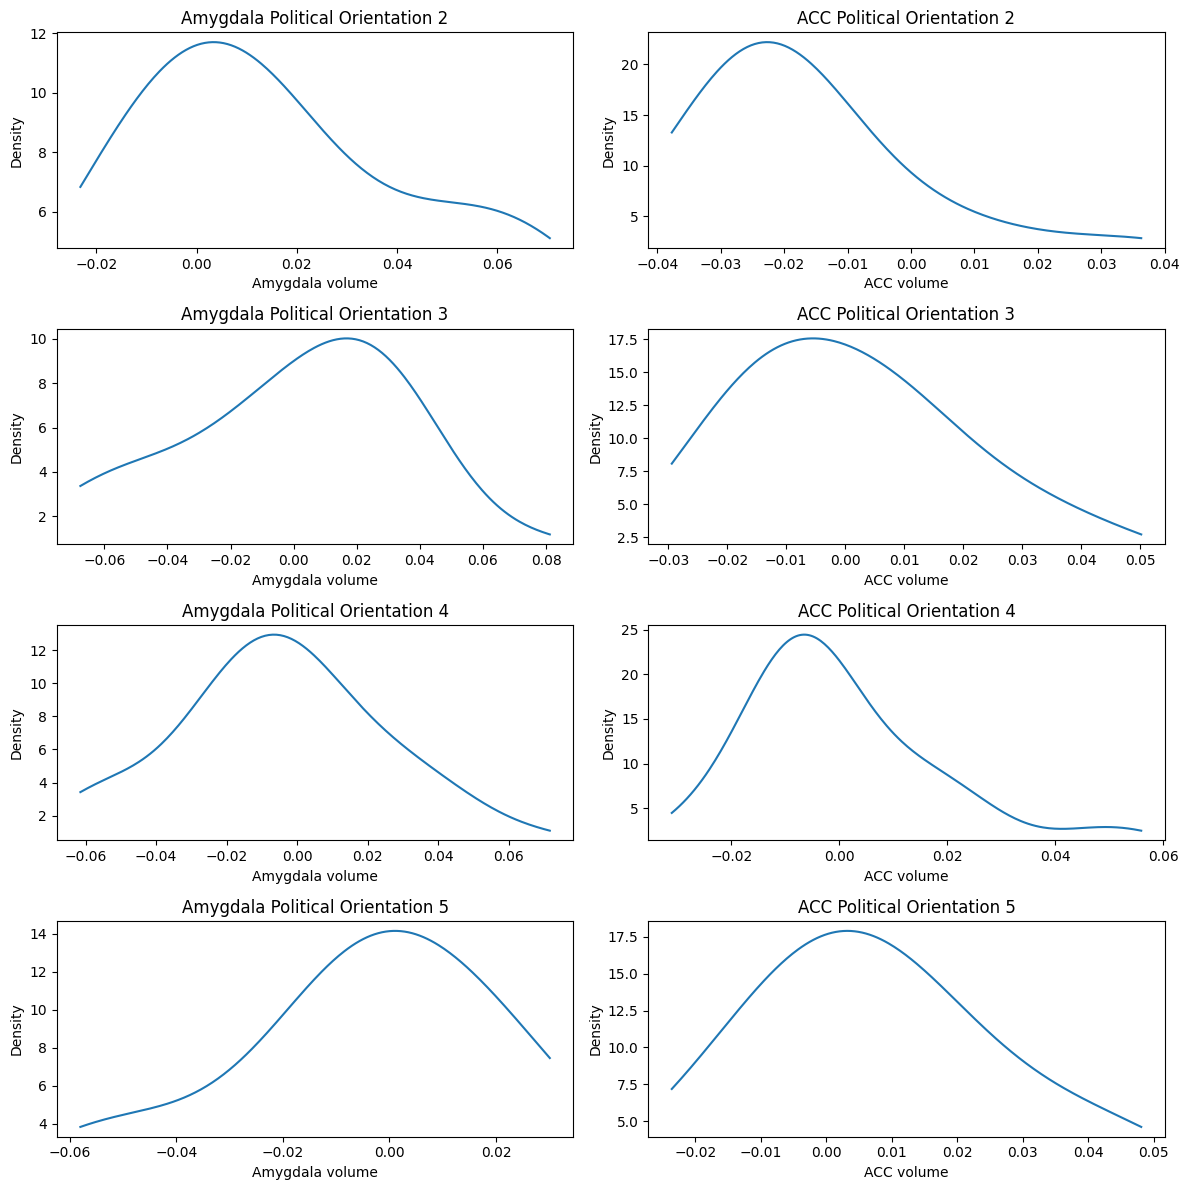

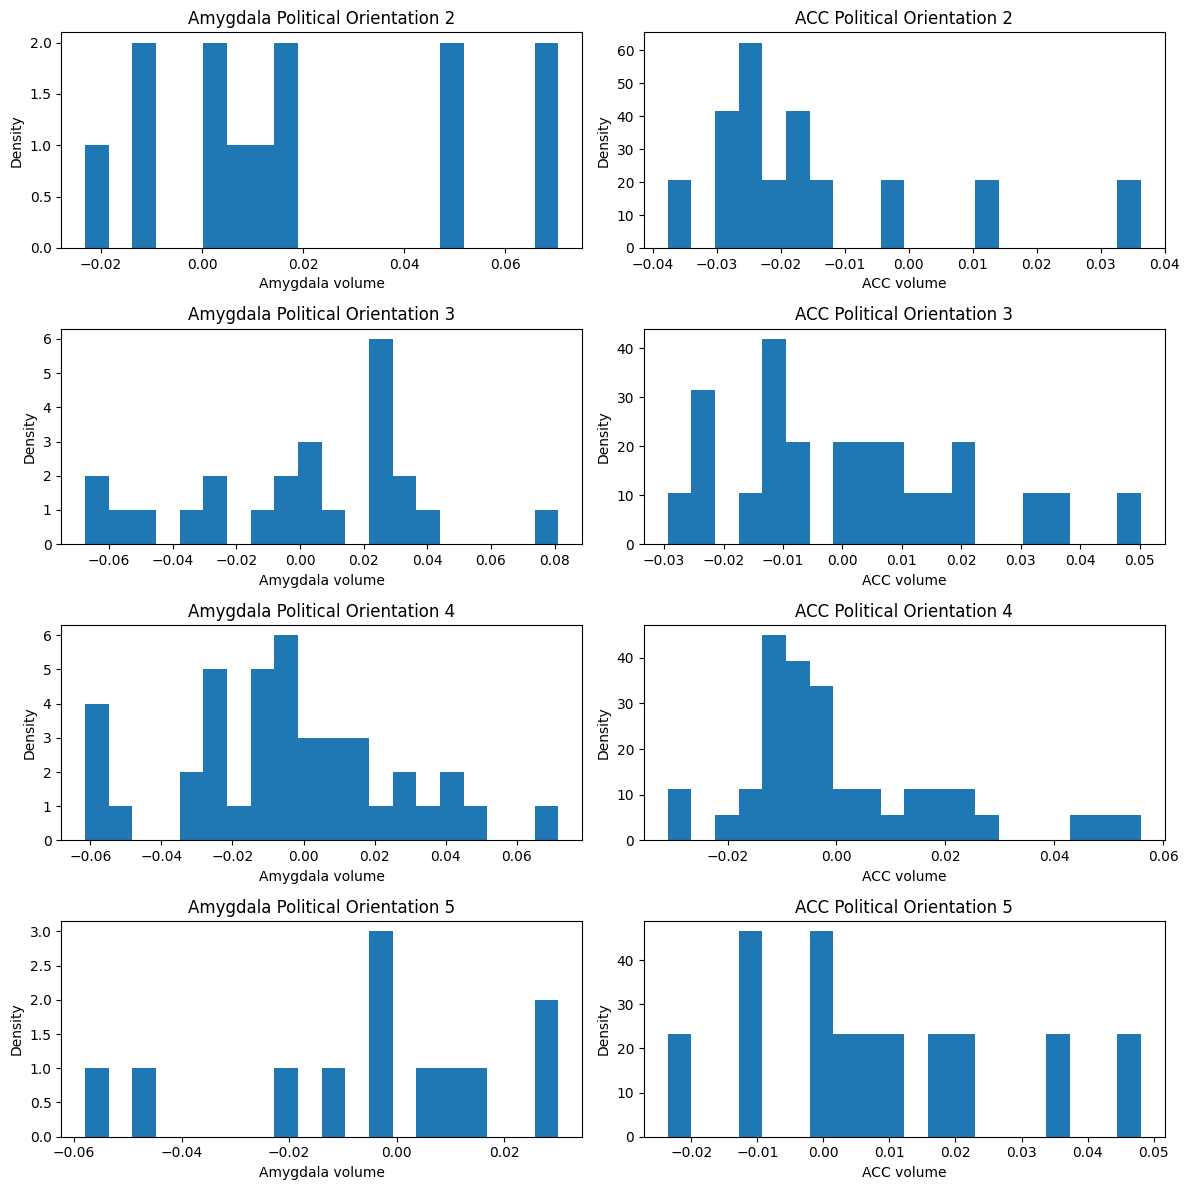

In [116]:
fig, axes = plt.subplots(len([2,3,4,5]), 2, figsize=(12, 3*len([2,3,4,5])))

bw_base = .2
for i, c in enumerate([2,3,4,5]):
    # Amygdala
    subsets = data[data[:,2]==c][:,0]

    kdes = stats.gaussian_kde(subsets, bw_method=bw_base / np.std(subsets, ddof=1))
    kdes,h=get_kde(subsets,len(subsets))
    grids = np.linspace(subsets.min(), subsets.max(), 250)

    axes[i,0].plot(grids, kdes(grids))
    axes[i,0].set_title(f'Amygdala Political Orientation {c}')
    axes[i,0].set_xlabel('Amygdala volume')
    axes[i,0].set_ylabel('Density')
  

    # ACC
    subsets_acc = data[data[:,2]==c][:,1]
    kdes_acc,_ = get_kde(subsets_acc,len(subsets_acc))
    grids_acc = np.linspace(subsets_acc.min(), subsets_acc.max(), 250)
    axes[i,1].plot(grids_acc, kdes_acc(grids_acc))
    axes[i,1].set_title(f'ACC Political Orientation {c}')
    axes[i,1].set_xlabel('ACC volume')
    axes[i,1].set_ylabel('Density')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len([2,3,4,5]), 2, figsize=(12, 3*len([2,3,4,5])))

bw_base = .2
for i, c in enumerate([2,3,4,5]):
    # Amygdala
    subsets = data[data[:,2]==c][:,0]
   
    grids = np.linspace(subsets.min(), subsets.max(), 250)
    axes[i, 0].hist(subsets, bins=20, density=False)

    
    axes[i,0].set_title(f'Amygdala Political Orientation {c}')
    axes[i,0].set_xlabel('Amygdala volume')
    axes[i,0].set_ylabel('Density')
  

    # ACC
    subsets_acc = data[data[:,2]==c][:,1]
    grids_acc = np.linspace(subsets_acc.min(), subsets_acc.max(), 250)
    axes[i, 1].hist(subsets_acc, bins=20, density=True)
    axes[i,1].set_title(f'ACC Political Orientation {c}')
    axes[i,1].set_xlabel('ACC volume')
    axes[i,1].set_ylabel('Density')

plt.tight_layout()
plt.show()



In [95]:
result_dict = {}
for i in [0,1]:
    for c in [2,3,4,5]:

        subsets = data[data[:,2]==c][:,i]
        result_dict[f"{i} - {c}"]=(np.mean(subsets))

In [96]:
result_dict

{'0 - 2': np.float64(0.01906153846153846),
 '0 - 3': np.float64(0.0005875),
 '0 - 4': np.float64(-0.004719512195121951),
 '0 - 5': np.float64(-0.005691666666666665),
 '1 - 2': np.float64(-0.014769230769230769),
 '1 - 3': np.float64(0.0016708333333333338),
 '1 - 4': np.float64(0.0013097560975609756),
 '1 - 5': np.float64(0.008141666666666667)}

Q2.6

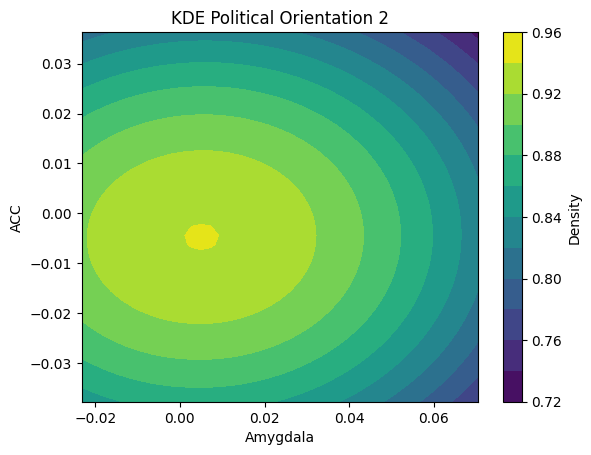

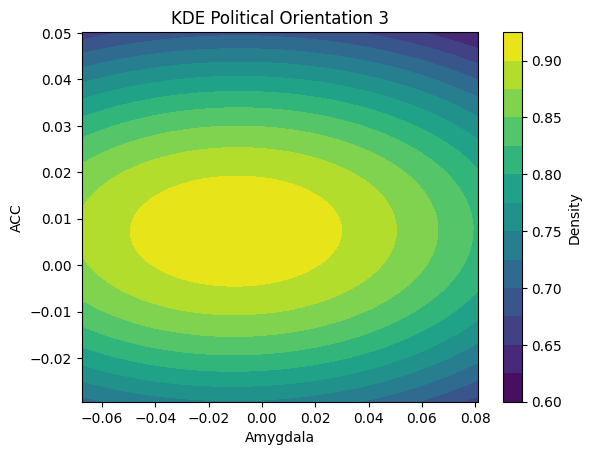

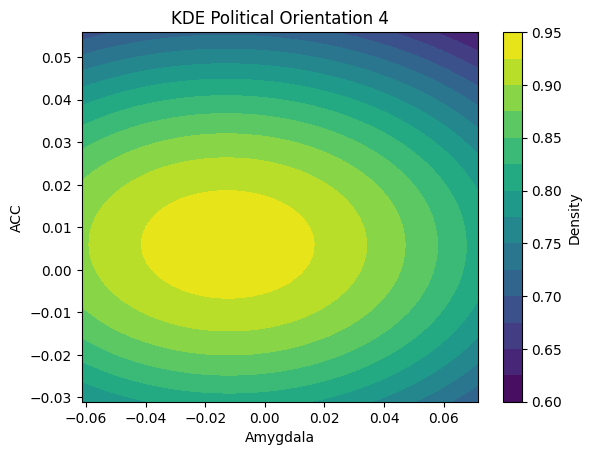

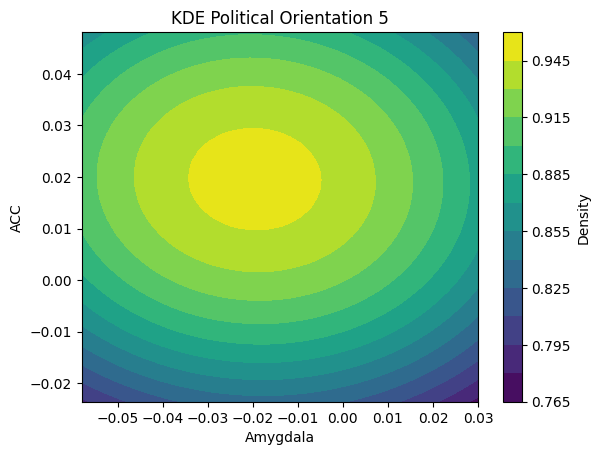

In [143]:

for i,c in enumerate([2,3,4,5]):
    datas =   data[data[:,2]==c]
    m = datas.shape[0]
    min_data = datas[:,:2].min(0)
    max_data = datas[:,:2].max(0)

    gridno = 40
    inc1 = (max_data[0] - min_data[0]) / gridno
    inc2 = (max_data[1] - min_data[1]) / gridno
    gridx, gridy = np.meshgrid(
        np.arange(min_data[0], max_data[0] + inc1, inc1),
        np.arange(min_data[1], max_data[1] + inc2, inc2),
    )

    gridall = [gridx.flatten(order="F"), gridy.flatten(order="F")]
    gridall = (np.asarray(gridall)).T
    gridallno, nn = gridall.shape
    norm_pdata = (np.power(datas[:,:2], 2)).sum(axis=1)
    norm_gridall = (np.power(gridall, 2)).sum(axis=1)
    cross = np.dot(datas[:,:2], gridall.T)

    diff = datas[:, None, :2] - gridall[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    bandwidth = .1

    kernelvalue = np.exp(-dist2/(2*bandwidth**2))


    mkde = kernelvalue.sum(axis=0) / m

    mkde = ((mkde).reshape(gridx.shape))
    
    
   
    plt.contourf(gridx, gridy, mkde, levels=12, cmap='viridis')
    plt.colorbar(label='Density')
    plt.xlabel('Amygdala')
    plt.ylabel('ACC')
    plt.title(f'KDE Political Orientation {c}')
    plt.show()  